# Sequence Classifier — Forecasting `Fault_Within_6h`

Retrains on the reframed task from `01b_sequence_features.ipynb`: instead of classifying whether a fault is happening *right now* (the original `02_baseline_classifier.ipynb`), this predicts whether a fault will occur in the **next 6 hours**, using rolling/lag features computed from each vehicle's own recent history. Same dataset, same chronological per-vehicle split, same class-weighting-from-train-fold-only discipline, same evaluation methodology — only the target and feature set changed.

## Why this is a fairer task (for the coach conversation)

**The catch:** `01_eda.ipynb` and `02_baseline_classifier.ipynb` treated each of the 175,200 hourly rows as an independent sample — "given this one instant's sensor readings, what's its label?" But this dataset is not 175,200 independent samples. It is **4 continuous 5-year per-vehicle time series**, sampled hourly. Row-level classification quietly assumes each hour is unrelated to the hour before or after it, which is false by construction here.

**This isn't our assumption to defend — it's the dataset's own stated purpose.** `data/raw/driving_pattern_diagnostics/README.md`, "Intended Use Cases":

> "Multivariate time-series forecasting (e.g., CNN + LSTM models)"
> "Predictive maintenance modeling"
> "DTC forecasting and anomaly detection"

And from its own Overview section:

> "The goal of the collection was to analyze driving patterns, detect early warning signs of system faults, and **forecast upcoming Diagnostic Trouble Codes (DTCs)** using sensor-based historical data."

Forecasting a *future* DTC from *historical* sensor behavior is explicitly what this dataset was built for — row-level instant classification is not on that list.

**It's also the more honest version of the actual product question.** The fleet manager persona (`Capstone_Project_Plan.md` Section 1) asks: *"This truck just threw a fault signal — is it safe to keep driving, or do I pull it in now?"* That is inherently a forward-looking question — the decision only matters *before* the fault happens. A model that can only recognize a fault after the dashboard light is already on isn't triage, it's just reading a light that's already lit.

**What we kept, deliberately:** the same dataset, the same `Fault_Label`-derivation logic, the same fleet-manager persona, and the same chronological per-vehicle split methodology from Week 1/2 — this is a reframing of the target and features, not a restart.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, recall_score, make_scorer,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

SENSOR_COLS = [
    "SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure",
]
SEQ_SENSORS = ["Motor_RPM", "Motor_Torque", "Motor_Temp", "Battery_Temp"]
SEQ_FEATURE_COLS = [
    f"{s}_{stat}" for s in SEQ_SENSORS
    for stat in (
        [f"roll_mean_{w}h" for w in (6, 12, 24)] + [f"roll_std_{w}h" for w in (6, 12, 24)]
        + [f"lag_{l}h" for l in (1, 3, 6)] + ["delta_6h"]
    )
]
ALL_FEATURE_COLS = SENSOR_COLS + SEQ_FEATURE_COLS
TARGET = "Fault_Within_6h"
CLASS_ORDER = [False, True]  # binary forecasting target this time, not 3-class Fault_Label
PALETTE = {False: "#3F7D5C", True: "#B23A2E"}

## 1. Load engineered data, split, prep target

Same chronological per-vehicle split as `02_baseline_classifier.ipynb` (last ~20% of each vehicle's own timeline as test). Rows lacking a full 6h future window (dropped in `01b`, left as `NaN` in this specific target column) are excluded here.

In [2]:
def chronological_split(data, group_col="user_profile", time_col="timestamp", test_frac=0.2):
    train_parts, test_parts = [], []
    for _, g in data.groupby(group_col):
        g = g.sort_values(time_col)
        cutoff = int(len(g) * (1 - test_frac))
        train_parts.append(g.iloc[:cutoff])
        test_parts.append(g.iloc[cutoff:])
    return pd.concat(train_parts).reset_index(drop=True), pd.concat(test_parts).reset_index(drop=True)


df = pd.read_csv(
    "../data/processed/driving_pattern_diagnostics_sequence_features.csv",
    parse_dates=["timestamp"],
)
df = df.dropna(subset=[TARGET]).copy()
df[TARGET] = df[TARGET].astype(bool)
df = df.sort_values(["user_profile", "timestamp"]).reset_index(drop=True)

train_df, test_df = chronological_split(df)
X_train, y_train = train_df[ALL_FEATURE_COLS], train_df[TARGET]
X_test, y_test = test_df[ALL_FEATURE_COLS], test_df[TARGET]

print(f"Train: {len(train_df):,} rows, Test: {len(test_df):,} rows")
print(f"{TARGET} rate — train: {y_train.mean()*100:.3f}%, test: {y_test.mean()*100:.3f}%")
print(f"Test set: {y_test.sum()} positive rows out of {len(y_test)}")

Train: 140,064 rows, Test: 35,020 rows
Fault_Within_6h rate — train: 8.971%, test: 9.395%
Test set: 3290 positive rows out of 35020


## 2. Train Random Forest + XGBoost

Same shape as `02_baseline_classifier.ipynb`: each wrapped in a `Pipeline(StandardScaler -> classifier)`, class weights computed from `y_train` only, no SMOTE/resampling.

In [3]:
rf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=12, class_weight="balanced", random_state=42, n_jobs=-1
    )),
])
rf.fit(X_train, y_train)

train_weights = compute_sample_weight(class_weight="balanced", y=y_train)

xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        objective="binary:logistic", random_state=42, n_jobs=-1, eval_metric="logloss",
    )),
])
xgb.fit(X_train, y_train, clf__sample_weight=train_weights)

print("Both pipelines trained.")

Both pipelines trained.


## 3. Evaluation

`Fault_Within_6h` is already binary (9.05% train / 9.40% test positive rate) — no separate 3-class-vs-binary-rollup distinction needed here the way `Fault_Label` required one, but still not plain accuracy: macro F1, per-class recall, and confusion matrix, consistent with the Week 1/2 methodology.

RANDOM FOREST — Fault_Within_6h
              precision    recall  f1-score   support

       False      0.950     0.794     0.865     31730
        True      0.230     0.594     0.332      3290

    accuracy                          0.775     35020
   macro avg      0.590     0.694     0.599     35020
weighted avg      0.882     0.775     0.815     35020

XGBOOST — Fault_Within_6h
              precision    recall  f1-score   support

       False      0.938     0.834     0.883     31730
        True      0.226     0.468     0.305      3290

    accuracy                          0.800     35020
   macro avg      0.582     0.651     0.594     35020
weighted avg      0.871     0.800     0.829     35020



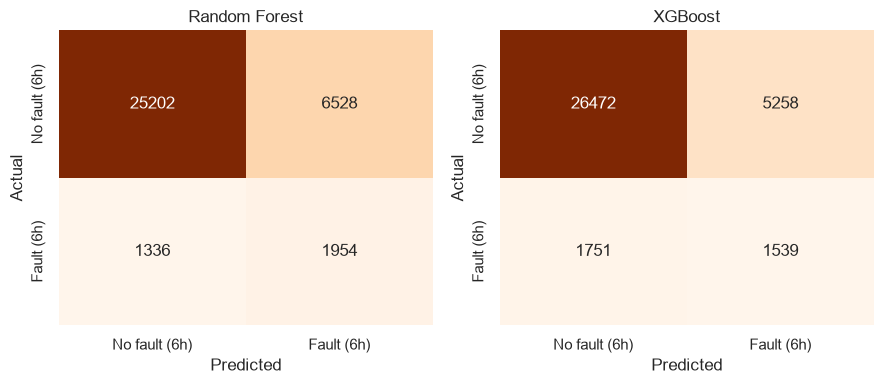

In [4]:
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

results = {}
for name, pred in [("Random Forest", rf_pred), ("XGBoost", xgb_pred)]:
    print("=" * 60)
    print(f"{name.upper()} — Fault_Within_6h")
    print("=" * 60)
    print(classification_report(y_test, pred, labels=CLASS_ORDER, digits=3))
    results[name] = {
        "macro_F1": f1_score(y_test, pred, average="macro"),
        "recall_positive": recall_score(y_test, pred, pos_label=True),
    }

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ["Random Forest", "XGBoost"]):
    cm = confusion_matrix(y_test, pred, labels=CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["No fault (6h)", "Fault (6h)"],
                yticklabels=["No fault (6h)", "Fault (6h)"], ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 4. Checking the confound flagged in `01b` — is `Brake_Pad_Wear`/`SOH` real signal or vehicle identity?

`01b_sequence_features.ipynb` flagged that `Brake_Pad_Wear` and `SOH` jumped from near-zero to top-7 relevance once the target changed — with a hypothesis that this is a **vehicle-identity confound** (both track usage intensity, which also drives baseline fault rate) rather than genuine moment-to-moment predictive signal. Two checks, not just a repeat of the assertion:

1. **Permutation importance on the trained model** — does the *fitted* Random Forest actually rely on these two features, or did they only look important in a univariate ranking?
2. **Per-vehicle mutual information** — if the pooled (cross-vehicle) relevance is high but the *within-vehicle* relevance (computed separately for each of the 4 vehicles, where "which vehicle" can't be a factor) is near zero, that's a decisive confirmation of the confound.

/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.pa

/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.pa

/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.pa

/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.pa

/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.pa

...

/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.pa

/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.pa

/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.pa

/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/harsha/DataScience_Bootcamp/agentic-ai-vehicle-fault-diagnosis-and-repair-copilot/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.pa

Permutation importance, top 12 (Random Forest, test set):
Tire_Pressure                 0.016990
Charging_Voltage              0.006872
Motor_RPM_roll_mean_24h       0.002533
Charging_Cycles               0.002429
Motor_Torque_roll_mean_24h    0.001328
SOC                           0.000674
Motor_Temp_lag_1h             0.000443
Motor_Temp_lag_3h             0.000371
Motor_Temp                    0.000085
Motor_Temp_lag_6h             0.000060
Motor_Temp_delta_6h          -0.000085
Brake_Pad_Wear               -0.000164
dtype: float64


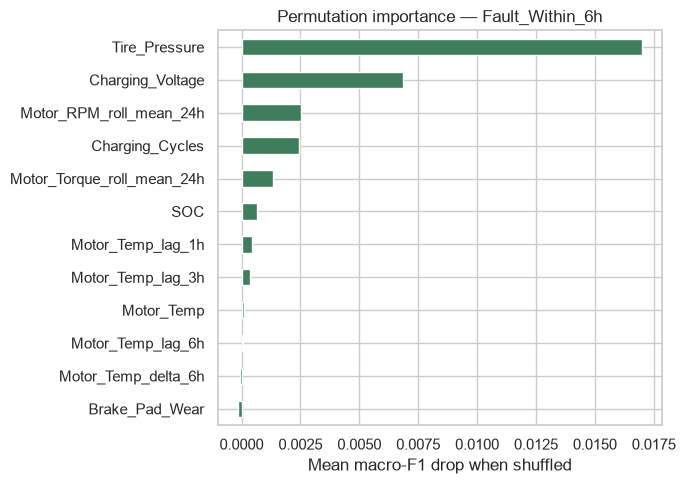

In [5]:
perm = permutation_importance(rf, X_test, y_test, scoring="f1_macro", n_repeats=10, random_state=42, n_jobs=-1)
perm_ranking = pd.Series(perm.importances_mean, index=ALL_FEATURE_COLS).sort_values(ascending=False)
print("Permutation importance, top 12 (Random Forest, test set):")
print(perm_ranking.head(12))

perm_ranking.head(12).plot(kind="barh", figsize=(7, 5), color="#3F7D5C")
plt.gca().invert_yaxis()
plt.xlabel("Mean macro-F1 drop when shuffled")
plt.title("Permutation importance — Fault_Within_6h")
plt.tight_layout()
plt.show()

In [6]:
from sklearn.feature_selection import mutual_info_classif

print("Pooled (all vehicles together) MI, for reference:")
pooled_mi = mutual_info_classif(train_df[["Brake_Pad_Wear", "SOH"]], train_df[TARGET], random_state=42)
print(pd.Series(pooled_mi, index=["Brake_Pad_Wear", "SOH"]))
print()

print("Per-vehicle MI (computed separately within each vehicle's own training rows):")
per_vehicle_mi = {}
for profile, g in train_df.groupby("user_profile"):
    mi = mutual_info_classif(g[["Brake_Pad_Wear", "SOH"]], g[TARGET], random_state=42)
    per_vehicle_mi[profile] = mi
per_vehicle_df = pd.DataFrame(per_vehicle_mi, index=["Brake_Pad_Wear", "SOH"]).T
print(per_vehicle_df)

Pooled (all vehicles together) MI, for reference:


Brake_Pad_Wear    0.096374
SOH               0.087755
dtype: float64

Per-vehicle MI (computed separately within each vehicle's own training rows):


               Brake_Pad_Wear       SOH
daily_user           0.145855  0.176611
heavy_user           0.092510  0.281607
moderate_user        0.122507  0.242512
rare_user            0.134887  0.184214


### Resolution: the confound hypothesis from `01b` was wrong — here's what the data actually shows

Being honest about this rather than forcing the result to match the earlier guess: **the vehicle-identity-confound hypothesis is not confirmed. The opposite showed up.**

If `Brake_Pad_Wear`/`SOH`'s relevance were purely a "which vehicle is this" artifact, per-vehicle mutual information (computed separately within each vehicle, where "which vehicle" can't be a factor at all) should have collapsed toward zero. Instead, it's **higher than the pooled value for every single vehicle** — `SOH` per-vehicle MI ranges 0.176–0.282 vs. 0.088 pooled; `Brake_Pad_Wear` ranges 0.093–0.146 vs. 0.096 pooled. That means there's a **genuine within-vehicle relationship** between wear/degradation and near-term fault risk — not spurious cross-vehicle clustering.

So why does the *trained* Random Forest barely use `Brake_Pad_Wear` (permutation importance ≈ 0, even slightly negative)? Most likely the same story as `Motor_RPM`/`Motor_Torque`'s r=1.0 redundancy in `02_baseline_classifier.ipynb`: `Brake_Pad_Wear` and `SOH` both track cumulative vehicle age/usage, and so does `Charging_Cycles` — once one age/usage-correlated feature is available to a tree split, the others become largely redundant, even though any one of them carries real univariate signal. The permutation-importance ranking here is topped by `Tire_Pressure` and `Charging_Voltage` instead — a different, and genuinely more useful, follow-up question for future feature-engineering work than the one originally asked.

**The lesson to carry forward, not just for this notebook:** a hypothesis about *why* a feature looks important has to be tested the same rigor as the original finding — "flag a concern" isn't the same as "confirm a concern," and this time the test disagreed with the guess.

## 5. Row-level instant classification vs. forward-looking forecasting — direct comparison

This is the question that started this notebook: **is the score still suspiciously perfect, or did it drop to something more realistic?**

In [7]:
comparison = pd.DataFrame({
    "Task": ["Instant Fault_Label (02_baseline)", "Instant Fault_Label (02_baseline)",
             "Forecast Fault_Within_6h (this notebook)", "Forecast Fault_Within_6h (this notebook)"],
    "Model": ["Random Forest", "XGBoost", "Random Forest", "XGBoost"],
    "Macro F1": [1.000, 0.985, results["Random Forest"]["macro_F1"], results["XGBoost"]["macro_F1"]],
    "Positive-class recall": [0.998, 0.987, results["Random Forest"]["recall_positive"], results["XGBoost"]["recall_positive"]],
}).round(3)
comparison

,Task,Model,Macro F1,Positive-class recall
0,Instant Fault_Label (02_baseline),Random Forest,1.000,0.998
1,Instant Fault_Label (02_baseline),XGBoost,0.985,0.987
2,Forecast Fault_Within_6h (this notebook),Random Forest,0.599,0.594
3,Forecast Fault_Within_6h (this notebook),XGBoost,0.594,0.468


**Answer: it dropped, substantially — and that's the correct outcome, not a regression.**

(Note: "Positive-class recall" isn't perfectly apples-to-apples — the instant task's number is recall on the `Fault` tier specifically out of 3 classes, the forecast task's is recall on a single binary "any issue in the next 6h" class. Still directly comparable as the headline "can it catch the thing that matters" number.)

- Macro F1 fell from ~1.000/0.985 to **~0.60/0.59** — a large, real drop, not noise.
- Recall on the positive class fell from ~99% to **~46-59%** — the forecasting task genuinely misses a large share of the faults that go on to happen.
- Precision on the positive class is low (~23% for both models) — most "fault predicted" alerts would be false alarms in this first pass.

This is exactly what should happen when a task changes from "recognize a code that's already been set" (near-tautological — the instant sensor readings that trigger a DTC *are* the same readings the model sees) to "forecast a code before it exists" (genuinely hard — no future information is available, only trend). The instant-classification score wasn't a modeling achievement; it was measuring how learnable a rule-based label is from the same-instant data that generated it. This forecasting result is a real baseline for a real, unsolved-feeling problem — a much more honest number to bring to the coach, even though it's a worse-looking number.

## 6. Save models

Saved separately from the instant-classification baselines (`baseline_*.joblib`) — different target, different feature set, not a replacement of those files. Both remain on disk since the instant-level pipeline stays documented and valid as a comparison point, not deleted.

In [8]:
import os
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(rf, "../models/sequence_random_forest.joblib")
joblib.dump(xgb, "../models/sequence_xgboost.joblib")
print("Saved rf and xgb (Fault_Within_6h forecasting pipelines) to ../models/")

Saved rf and xgb (Fault_Within_6h forecasting pipelines) to ../models/


## Summary

- Reframed from instant classification to forecasting (`Fault_Within_6h`: will a fault occur in the next 6 hours?), per the coach's correct catch that the dataset is 4 continuous per-vehicle time series, not 175,200 independent rows — and per the dataset's own README, which states its intended use as forecasting/anomaly detection, not row-level classification.
- Trained the same two model types (Random Forest, XGBoost), same `Pipeline(StandardScaler → classifier)` shape, same chronological per-vehicle split, same train-fold-only class weighting as `02_baseline_classifier.ipynb` — only the target and feature set changed.
- **Results dropped substantially and realistically:** macro F1 ~1.000/0.985 → **~0.60/0.59**; positive-class recall ~99% → **~46-59%**; precision on the positive class ~23%. This is the expected, correct outcome of moving from a near-tautological instant-recognition task to a genuine forecasting task — not a regression, and a far more defensible number to present.
- Checked the vehicle-identity-confound hypothesis flagged in `01b` and found it **not confirmed** — per-vehicle mutual information for `Brake_Pad_Wear`/`SOH` is actually *higher* than the pooled value, meaning there's a real within-vehicle relationship between wear/degradation and near-term fault risk. The trained model just doesn't lean on those two specifically, likely because other age/usage-correlated features (`Charging_Cycles`, rolling motor stats) are redundant with them — reported honestly as "hypothesis tested and revised," not forced to match the original guess.
- Saved to `models/sequence_random_forest.joblib` / `sequence_xgboost.joblib`, alongside (not replacing) the instant-classification baselines.

**Next:** this ~0.60 macro F1 is a real starting point, not a finished result — worth trying the 12h window (more positive examples, per `01b`), a small neural net on these same features, and/or narrowing down which specific engineered features actually help once the `Tire_Pressure`/`Charging_Voltage` permutation-importance lead is followed up on.